# Machine Learning-Based Stroke Prediction: Evaluating the Impact of Data Preprocessing Techniques

## 06_Comparison: Final Pipeline Comparison


## Introduction

### Research Objective

In this notebook, I bring together the results from the earlier experiments and choose the final stroke prediction pipeline.

I compare the choices for missing values, outliers, encoding, scaling, and model selection. These steps need to be considered together because each one changes the data used by the model.


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TABLES_DIR = PROJECT_ROOT / "results" / "tables"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TARGET_COLUMN = "stroke"

missing_method_comparison = pd.read_csv(TABLES_DIR / "missing_value_method_comparison.csv")
missing_sample_comparison = pd.read_csv(TABLES_DIR / "missing_value_method_sample_comparison.csv")
outlier_treatment_summary = pd.read_csv(TABLES_DIR / "outlier_treatment_summary.csv")
outlier_before_after = pd.read_csv(TABLES_DIR / "outlier_before_after_comparison.csv")
scaling_comparison = pd.read_csv(TABLES_DIR / "preprocessing_scaling_comparison.csv")
preprocessing_summary = pd.read_csv(TABLES_DIR / "preprocessing_final_dataset_summary.csv")
model_performance = pd.read_csv(TABLES_DIR / "model_performance_comparison.csv")
best_model_summary = pd.read_csv(TABLES_DIR / "best_model_summary.csv")

train_no_scaling = pd.read_csv(PROCESSED_DIR / "stroke_train_no_scaling.csv")
test_no_scaling = pd.read_csv(PROCESSED_DIR / "stroke_test_no_scaling.csv")

display(model_performance)

,model,accuracy,precision,recall,f1_score
0,Logistic Regression,0.7456,0.1379,0.80,0.2353
1,Random Forest,0.9344,0.1852,0.10,0.1299
2,XGBoost,0.8160,0.1745,0.74,0.2824


## Missing Value Comparison

Notebook 02 compared row deletion, mean, median, and KNN imputation for BMI.

I chose median imputation because it keeps all rows, handles extreme values better than the mean, and is easy to explain. Row deletion loses patient records, while KNN adds more settings and complexity.


In [2]:
display(missing_sample_comparison)
display(missing_method_comparison)

missing_value_summary = pd.DataFrame([
    {
        "component": "Missing-value handling",
        "methods_compared": "Delete Rows, Mean Imputation, Median Imputation, KNN Imputation",
        "recommended_method": "Median Imputation",
        "reason": "Preserves sample size, is robust to outliers, and remains transparent for dissertation reporting."
    }
])
missing_value_summary.to_csv(TABLES_DIR / "comparison_missing_value_summary.csv", index=False)
display(missing_value_summary)

,method,rows,rows_removed,bmi_missing_after_processing,stroke_cases,stroke_percentage
0,delete_rows,4909,201,0,209,4.26
1,mean_imputation,5110,0,0,249,4.87
2,median_imputation,5110,0,0,249,4.87
3,knn_imputation,5110,0,0,249,4.87


,method,advantages,disadvantages,suitability
0,Delete Rows,"Simple, transparent, uses only observed BMI va...",Reduces sample size and may bias the dataset i...,"Useful as a sensitivity analysis, but not pref..."
1,Mean Imputation,"Simple, reproducible, preserves all rows, easy...",Sensitive to outliers and can reduce variance ...,Acceptable only as a basic benchmark; less rob...
2,Median Imputation,"Simple, robust to outliers, preserves all rows...",Still creates repeated values and does not use...,Recommended primary method for this project be...
3,KNN Imputation,Uses multivariable similarity and can produce ...,"More complex, sensitive to scaling and feature...","Useful as a secondary comparison method, but l..."


,component,methods_compared,recommended_method,reason
0,Missing-value handling,"Delete Rows, Mean Imputation, Median Imputatio...",Median Imputation,"Preserves sample size, is robust to outliers, ..."


## Outlier Comparison

Notebook 03 used the IQR method on BMI and average glucose level. It removed many rows, and some of those extreme values may be valid patient data.

I therefore keep outliers in the main pipeline. The IQR-treated data can still be used for a sensitivity test.


In [3]:
display(outlier_treatment_summary)
display(outlier_before_after)

outlier_summary = pd.DataFrame([
    {
        "component": "Outlier treatment",
        "methods_compared": "Original Dataset, IQR-Treated Dataset",
        "recommended_method": "Retain outliers in primary pipeline",
        "reason": "BMI and glucose extremes may be clinically meaningful; IQR removal reduced the dataset and may remove high-risk cases."
    }
])
outlier_summary.to_csv(TABLES_DIR / "comparison_outlier_summary.csv", index=False)
display(outlier_summary)

,metric,value
0,Original rows,5110
1,IQR-treated rows,4401
2,BMI outliers detected,110
3,Glucose outliers detected,627
4,Unique records flagged as outliers,709
5,Rows removed,709


,dataset,rows,bmi_mean,bmi_median,bmi_std,glucose_mean,glucose_median,glucose_std,stroke_cases,stroke_percentage
0,Original Dataset,5110,28.893,28.1,7.854,106.148,91.885,45.284,249,4.873
1,IQR-Treated Dataset,4401,27.812,27.4,6.721,91.484,88.040,22.664,165,3.749


,component,methods_compared,recommended_method,reason
0,Outlier treatment,"Original Dataset, IQR-Treated Dataset",Retain outliers in primary pipeline,BMI and glucose extremes may be clinically mea...


## Scaling Comparison

Notebook 04 created scaled and unscaled feature sets. Logistic Regression uses the scaled version. Random Forest and XGBoost use the unscaled version because tree models do not usually need scaling.

All versions use the same stratified train/test split, so the model comparison stays consistent.


In [4]:
display(scaling_comparison)
display(preprocessing_summary)

scaling_summary = pd.DataFrame([
    {
        "component": "Scaling strategy",
        "methods_compared": "No Scaling, StandardScaler",
        "recommended_method": "Model-dependent scaling",
        "reason": "Use StandardScaler for scale-sensitive models and no scaling for tree-based models."
    }
])
scaling_summary.to_csv(TABLES_DIR / "comparison_scaling_summary.csv", index=False)
display(scaling_summary)

,variant,description,best_suited_models,limitation
0,No Scaling,Encoded features retained on original numeric ...,Tree-based methods and baseline comparison.,Scale-sensitive models may be dominated by lar...
1,StandardScaler,Numerical features standardised to zero mean a...,"Logistic regression, SVM, KNN, neural networks...",Less necessary for tree-based models and sligh...


,metric,value
0,Final dataset rows,5110
1,Final dataset columns including target,17
2,Generated features after encoding,16
3,Training rows,4088
4,Test rows,1022


,component,methods_compared,recommended_method,reason
0,Scaling strategy,"No Scaling, StandardScaler",Model-dependent scaling,Use StandardScaler for scale-sensitive models ...


## Model Comparison

Notebook 05 compared Logistic Regression, Random Forest, and XGBoost on the same data split.

I report accuracy, precision, recall, and F1 score. Recall and F1 are the main focus because stroke cases are rare.


,model,accuracy,precision,recall,f1_score
0,Logistic Regression,0.7456,0.1379,0.80,0.2353
1,Random Forest,0.9344,0.1852,0.10,0.1299
2,XGBoost,0.8160,0.1745,0.74,0.2824


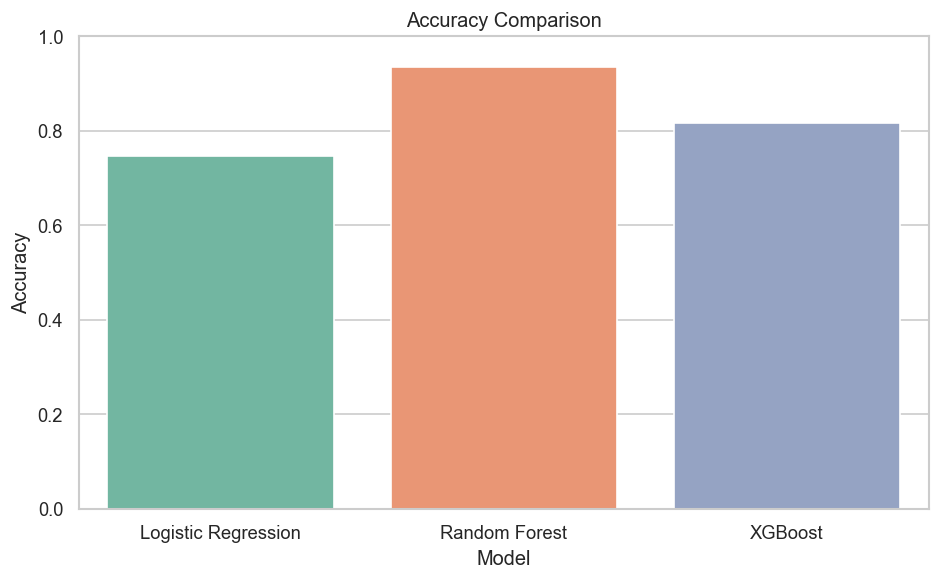

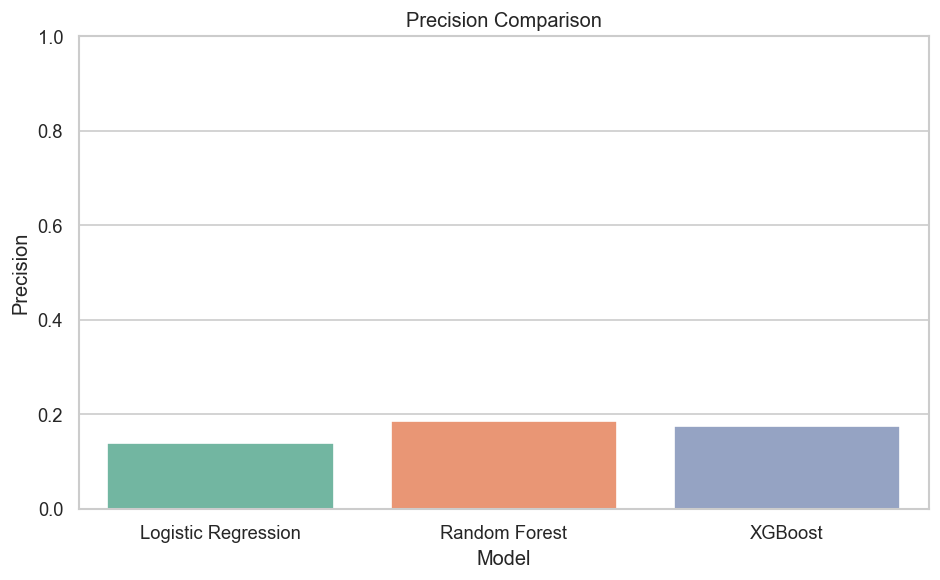

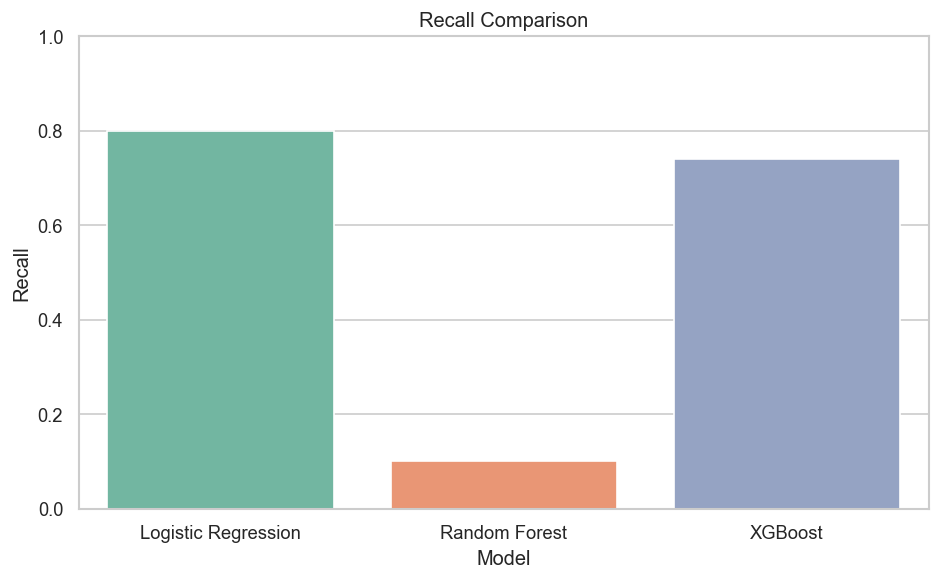

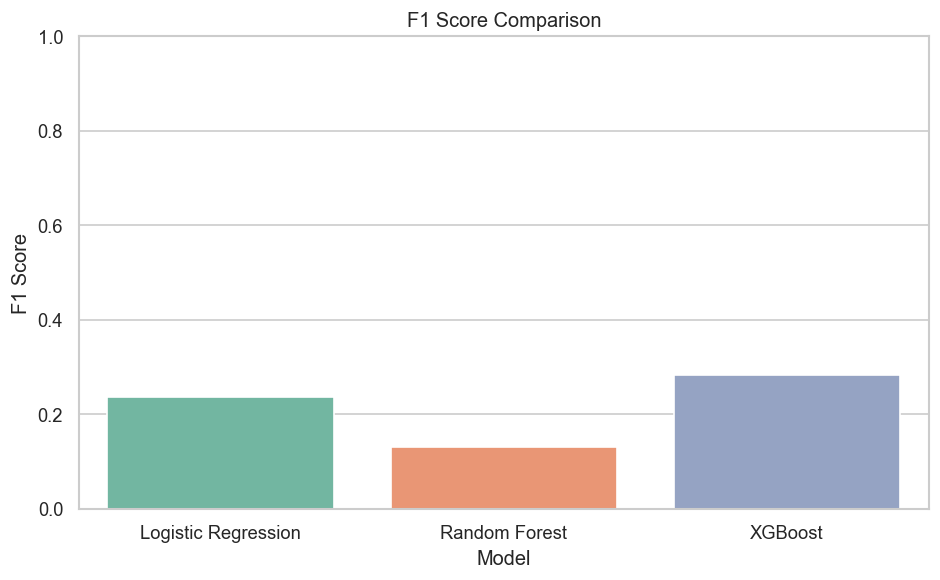

,criterion,model
0,Best model based on F1 Score,XGBoost
1,Best model based on Recall,Logistic Regression


In [5]:
display(model_performance)

metric_files = {
    "accuracy": "final_accuracy_comparison_chart.png",
    "precision": "final_precision_comparison_chart.png",
    "recall": "final_recall_comparison_chart.png",
    "f1_score": "final_f1_score_comparison_chart.png"
}

for metric, filename in metric_files.items():
    plt.figure(figsize=(8, 5))
    sns.barplot(data=model_performance, x="model", y=metric, hue="model", palette="Set2", legend=False)
    plt.title(f"{metric.replace('_', ' ').title()} Comparison")
    plt.xlabel("Model")
    plt.ylabel(metric.replace("_", " ").title())
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, bbox_inches="tight")
    plt.show()

best_f1_model = model_performance.loc[model_performance["f1_score"].idxmax(), "model"]
best_recall_model = model_performance.loc[model_performance["recall"].idxmax(), "model"]
display(best_model_summary)

### Feature Importance: Random Forest and XGBoost

These charts show which features the tree models use most. They are useful for exploration, but they do not prove that a feature causes stroke. The values can also change when features are related to each other.


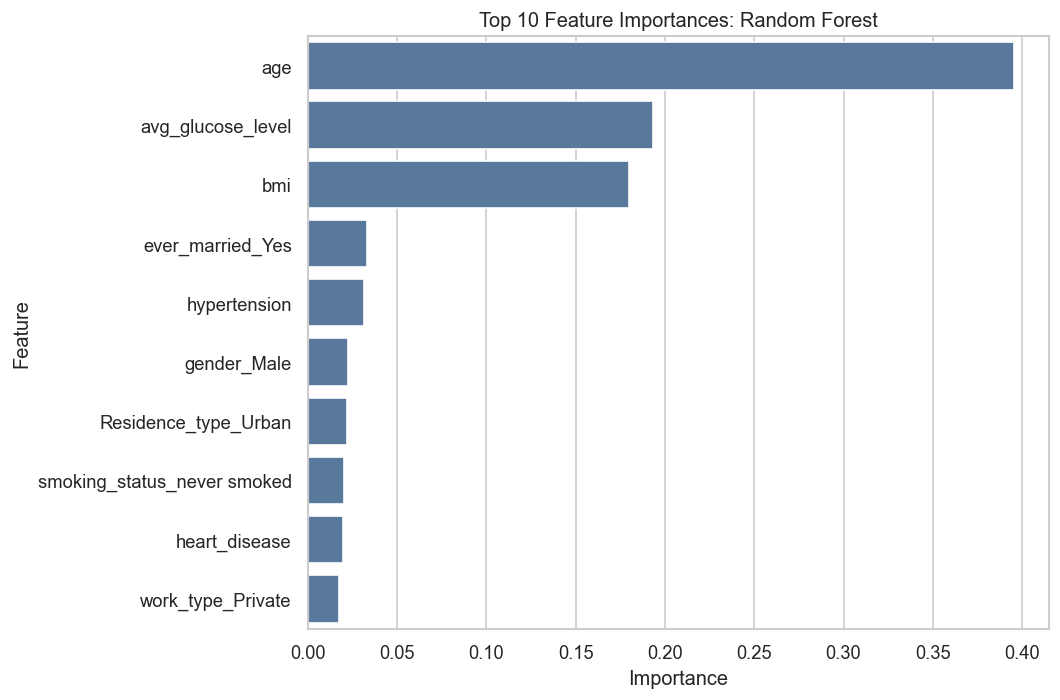

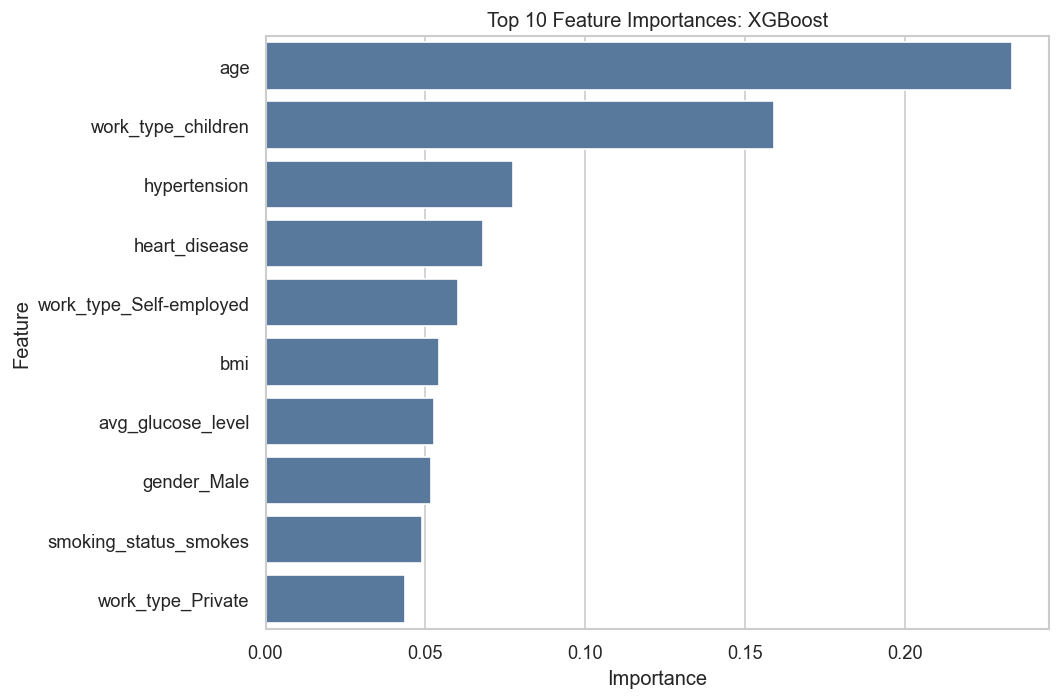

,feature,importance,model
0,age,0.395135,Random Forest
1,avg_glucose_level,0.193228,Random Forest
2,bmi,0.179990,Random Forest
3,ever_married_Yes,0.033463,Random Forest
4,hypertension,0.031500,Random Forest
5,gender_Male,0.022587,Random Forest
6,Residence_type_Urban,0.022103,Random Forest
7,smoking_status_never smoked,0.020440,Random Forest
8,heart_disease,0.019572,Random Forest
9,work_type_Private,0.017632,Random Forest


In [6]:
X_train = train_no_scaling.drop(columns=[TARGET_COLUMN])
y_train = train_no_scaling[TARGET_COLUMN]

negative_cases = (y_train == 0).sum()
positive_cases = (y_train == 1).sum()
scale_pos_weight = negative_cases / positive_cases

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

rf_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_,
    "model": "Random Forest"
}).sort_values("importance", ascending=False)

xgb_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_,
    "model": "XGBoost"
}).sort_values("importance", ascending=False)

feature_importance_table = pd.concat([rf_importance, xgb_importance], ignore_index=True)
feature_importance_table.to_csv(TABLES_DIR / "final_feature_importance_random_forest_xgboost.csv", index=False)

for model_name, importance_df, filename in [
    ("Random Forest", rf_importance, "feature_importance_random_forest.png"),
    ("XGBoost", xgb_importance, "feature_importance_xgboost.png")
]:
    top_features = importance_df.head(10)
    plt.figure(figsize=(9, 6))
    sns.barplot(data=top_features, x="importance", y="feature", color="#4C78A8")
    plt.title(f"Top 10 Feature Importances: {model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, bbox_inches="tight")
    plt.show()

display(feature_importance_table.groupby("model").head(10))

## Best Pipeline

The final preprocessing choices are median BMI imputation, keeping outliers, one-hot encoding, and model-based scaling.

I use F1 score as the main rule for model selection because it balances precision and recall. I also report recall separately because missing a stroke case is important.


In [7]:
best_model = best_f1_model
best_preprocessing_strategy = "Median BMI imputation, retain outliers, one-hot encoding, model-dependent scaling, stratified train/test split"
final_recommended_pipeline = f"{best_preprocessing_strategy}, followed by {best_model} for stroke prediction"

final_comparison_table = pd.DataFrame([
    {
        "pipeline_component": "Missing-value handling",
        "methods_compared": "Delete Rows, Mean Imputation, Median Imputation, KNN Imputation",
        "selected_option": "Median Imputation",
        "justification": "Robust to outliers, preserves all records, and is transparent."
    },
    {
        "pipeline_component": "Outlier treatment",
        "methods_compared": "Original Dataset, IQR-Treated Dataset",
        "selected_option": "Retain outliers",
        "justification": "Extreme BMI and glucose values may be clinically meaningful."
    },
    {
        "pipeline_component": "Categorical preprocessing",
        "methods_compared": "Raw categories, One-Hot Encoding",
        "selected_option": "One-Hot Encoding",
        "justification": "Allows categorical variables to be used without imposing false ordinal relationships."
    },
    {
        "pipeline_component": "Scaling",
        "methods_compared": "No Scaling, StandardScaler",
        "selected_option": "Model-dependent scaling",
        "justification": "StandardScaler for scale-sensitive models; no scaling for tree-based models."
    },
    {
        "pipeline_component": "Machine learning model",
        "methods_compared": "Logistic Regression, Random Forest, XGBoost",
        "selected_option": best_model,
        "justification": "Best model based on F1 score in the current model comparison."
    }
])

final_recommendation_table = pd.DataFrame([
    {"item": "Best preprocessing strategy", "recommendation": best_preprocessing_strategy},
    {"item": "Best model", "recommendation": best_model},
    {"item": "Best model based on recall", "recommendation": best_recall_model},
    {"item": "Final recommended stroke prediction pipeline", "recommendation": final_recommended_pipeline}
])

final_comparison_table.to_csv(TABLES_DIR / "final_comparison_table.csv", index=False)
final_recommendation_table.to_csv(TABLES_DIR / "final_recommended_pipeline.csv", index=False)

display(final_comparison_table)
display(final_recommendation_table)

,pipeline_component,methods_compared,selected_option,justification
0,Missing-value handling,"Delete Rows, Mean Imputation, Median Imputatio...",Median Imputation,"Robust to outliers, preserves all records, and..."
1,Outlier treatment,"Original Dataset, IQR-Treated Dataset",Retain outliers,Extreme BMI and glucose values may be clinical...
2,Categorical preprocessing,"Raw categories, One-Hot Encoding",One-Hot Encoding,Allows categorical variables to be used withou...
3,Scaling,"No Scaling, StandardScaler",Model-dependent scaling,StandardScaler for scale-sensitive models; no ...
4,Machine learning model,"Logistic Regression, Random Forest, XGBoost",XGBoost,Best model based on F1 score in the current mo...


,item,recommendation
0,Best preprocessing strategy,"Median BMI imputation, retain outliers, one-ho..."
1,Best model,XGBoost
2,Best model based on recall,Logistic Regression
3,Final recommended stroke prediction pipeline,"Median BMI imputation, retain outliers, one-ho..."


## Discussion

Median imputation keeps all patient records, which helps when the number of stroke cases is already small. I also keep extreme BMI and glucose values because they may describe real high-risk patients.

The results show why accuracy is not enough for this dataset. A model can predict the large non-stroke class well and still miss many stroke cases. XGBoost has the best F1 score in the current results, while Logistic Regression has the best recall.

I select XGBoost as the best overall model because of its F1 score. However, Logistic Regression is still worth discussing if finding as many stroke cases as possible is the main goal.


## Limitations

This dataset is observational, so it cannot show that a feature causes stroke. The stroke class is also very small, and results from one train/test split may change with a different split.

The missing BMI values are unknown, so no imputation method can recover the exact values. The IQR rule may also mark valid clinical values as outliers.

This is an early model comparison. It does not include full parameter tuning, threshold tuning, external testing, or calibration. The current models should not be treated as ready for clinical use.


## Future Work

The next step would be stratified cross-validation, which would make the results less dependent on one data split. Random Forest and XGBoost would also benefit from parameter tuning.

I would also test different decision thresholds and add ROC-AUC, PR-AUC, specificity, and calibration curves. SMOTE, undersampling, and other class-weight settings could be compared as well.

Finally, the pipeline would need testing on a separate dataset before making any claims about real-world use.


## Conclusion

The final preprocessing pipeline uses median BMI imputation, keeps outliers, applies one-hot encoding, scales features when the model needs it, and uses a stratified train/test split.

XGBoost has the best F1 score, so I select it as the best overall model in this comparison. Logistic Regression has stronger recall, which is still important when the cost of missing stroke cases is high.
